Resumes DataFrame columns: ['id', 'name', 'education', 'skills', 'experience', 'previous_jobs', 'fresher_flag']
Jobs DataFrame columns: ['title', 'department', 'location', 'required_skills', 'experience_required', 'education_required', 'certifications_required', 'job_description']
Top 3 Job Matches per Candidate:

Candidate: Candidate_1
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_2
  Match 1: Project Manager (37.58%)
  Match 2: Backend Developer (32.85%)
  Match 3: DevOps Engineer (21.67%)

Candidate: Candidate_3
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_4
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)

Candidate: Candidate_5
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)



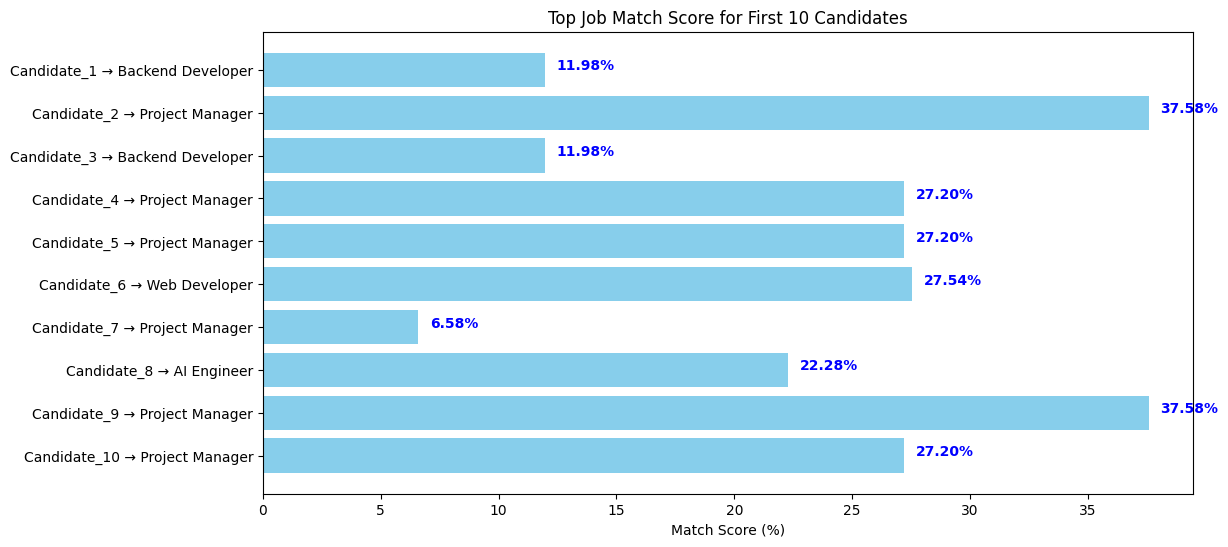

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load datasets
resumes_df = pd.read_csv("resumes_dataset_400.csv")
jobs_df = pd.read_csv("job_descriptions_50.csv")

# Check what columns are available
print("Resumes DataFrame columns:", resumes_df.columns.tolist())
print("Jobs DataFrame columns:", jobs_df.columns.tolist())

# Preprocessing function
def preprocess_skills(skills_text):
    skills_text = str(skills_text).lower()
    skills_text = re.sub(r'[^a-z,\s]', '', skills_text)  # keep only letters and commas
    tokens = [t.strip() for t in skills_text.split(",") if t.strip()]
    tokens = list(set(tokens))  # remove duplicates
    return ' '.join(tokens)

# Clean skills - ADJUST THESE COLUMN NAMES based on what you saw in the print output
# For example, if your columns are named 'skills' and 'required_skills':
resumes_df['cleaned_skills'] = resumes_df['skills'].apply(preprocess_skills)  # Adjust column name
jobs_df['cleaned_required_skills'] = jobs_df['required_skills'].apply(preprocess_skills)  # Adjust column name

# TF-IDF vectorization
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w+')
vectorizer.fit(pd.concat([resumes_df['cleaned_skills'], jobs_df['cleaned_required_skills']]))

resume_vectors = vectorizer.transform(resumes_df['cleaned_skills'])
job_vectors = vectorizer.transform(jobs_df['cleaned_required_skills'])

# Cosine similarity
match_scores = cosine_similarity(resume_vectors, job_vectors)

# Display top 3 matches for first 5 candidates
print("Top 3 Job Matches per Candidate:\n")
for i in range(5):
    candidate_name = resumes_df.loc[i, 'name']
    scores = match_scores[i]
    top_jobs = scores.argsort()[-3:][::-1]  # top 3 job indexes
    print(f"Candidate: {candidate_name}")
    for rank, job_idx in enumerate(top_jobs, start=1):
        job_title = jobs_df.loc[job_idx, 'title']
        score = scores[job_idx] * 100
        print(f"  Match {rank}: {job_title} ({score:.2f}%)")
    print()

# Visualization: Top job match for first 10 candidates
top_matches = []
for i in range(10):
    best_job_index = match_scores[i].argmax()
    score = match_scores[i][best_job_index] * 100
    candidate_name = resumes_df.loc[i, 'name']
    job_title = jobs_df.loc[best_job_index, 'title']
    top_matches.append((f"{candidate_name} → {job_title}", score))

# Plot
labels, scores = zip(*top_matches)
plt.figure(figsize=(12,6))
plt.barh(labels, scores, color="skyblue")
plt.xlabel("Match Score (%)")
plt.title("Top Job Match Score for First 10 Candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}%", color="blue", fontweight="bold")
plt.show()

Resumes DataFrame columns: ['id', 'name', 'education', 'skills', 'experience', 'previous_jobs', 'fresher_flag']
Jobs DataFrame columns: ['title', 'department', 'location', 'required_skills', 'experience_required', 'education_required', 'certifications_required', 'job_description']
Top 3 Job Matches per Candidate:

Candidate: Candidate_1
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_2
  Match 1: Project Manager (37.58%)
  Match 2: Backend Developer (32.85%)
  Match 3: DevOps Engineer (21.67%)

Candidate: Candidate_3
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_4
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)

Candidate: Candidate_5
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)



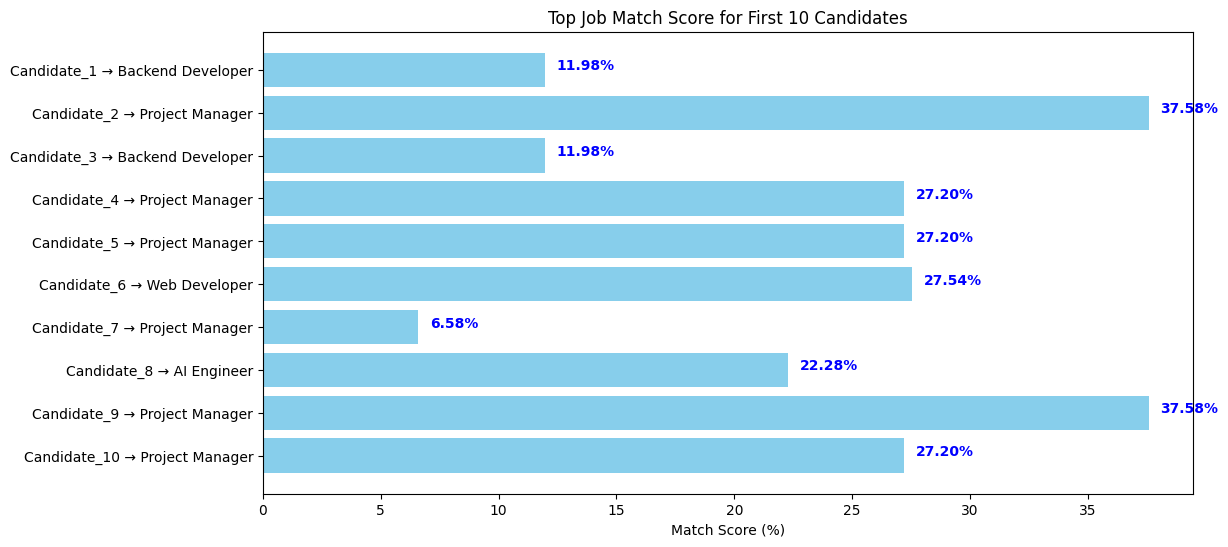


JOB DESCRIPTION INPUT

Top 5 Candidates for 'Web Devloper':
--------------------------------------------------
1. Candidate_6
   Match Score: 56.71%
   Skills: css react java html

2. Candidate_371
   Match Score: 56.71%
   Skills: css react java html

3. Candidate_48
   Match Score: 56.71%
   Skills: css react java html

4. Candidate_44
   Match Score: 56.71%
   Skills: css react java html

5. Candidate_42
   Match Score: 56.71%
   Skills: css react java html



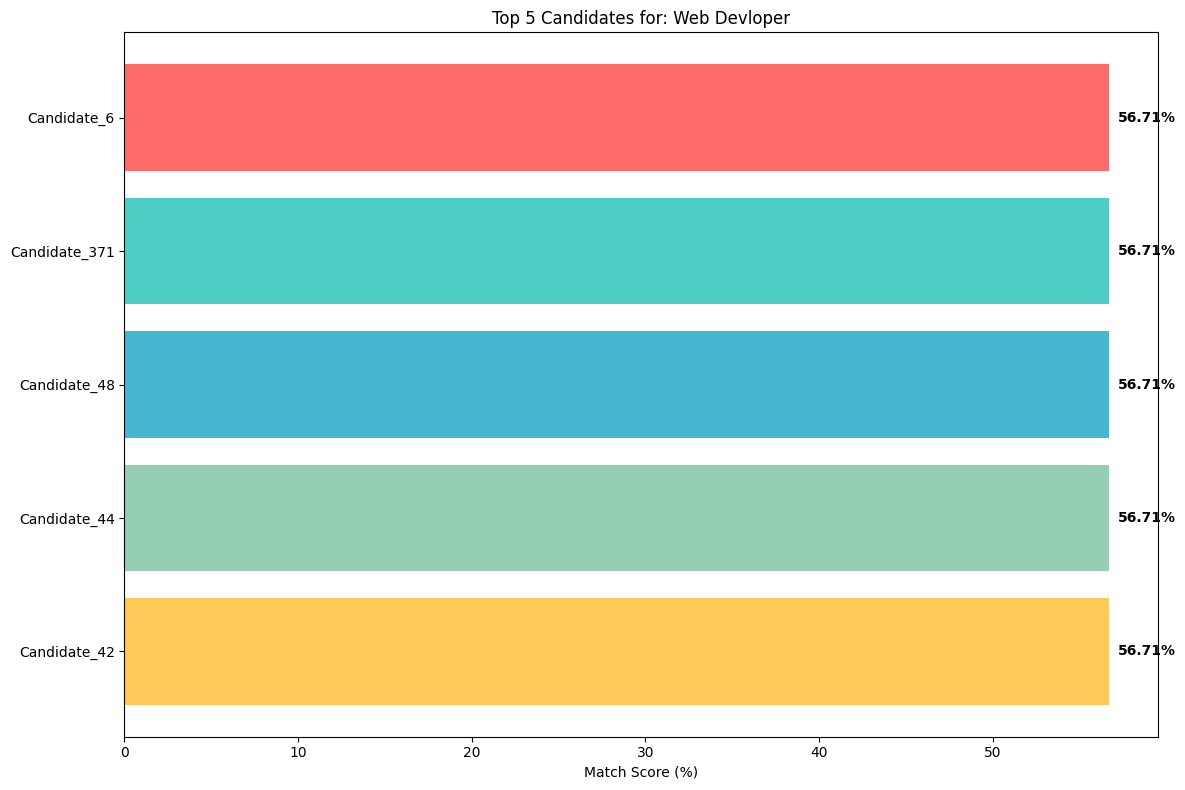

(array([  5, 370,  47,  43,  41]),
 array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.56714843, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.56714843, 0.        , 0.        , 0.56714843,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.56714843,
         0.        , 0.        , 0.        , 0.        , 0.56714843,
         0.        , 0.56714843, 0.        , 0.56714843, 0.        ,
         0.        , 0.        , 0.56714843, 0.        , 0.        ,
         0.        , 0.56714843, 0.        , 0.        , 0.56714843,
         0.        , 0.56714843, 0.        , 0.        , 0.        ,
         0.        , 0.56714843, 0.        , 0.        , 0.        ,
         0.56714843, 0.        , 0.        , 0.56714843, 0.        ,

In [2]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load datasets
resumes_df = pd.read_csv("resumes_dataset_400.csv")
jobs_df = pd.read_csv("job_descriptions_50.csv")

# Check what columns are available
print("Resumes DataFrame columns:", resumes_df.columns.tolist())
print("Jobs DataFrame columns:", jobs_df.columns.tolist())

# Preprocessing function
def preprocess_skills(skills_text):
    skills_text = str(skills_text).lower()
    skills_text = re.sub(r'[^a-z,\s]', '', skills_text)  # keep only letters and commas
    tokens = [t.strip() for t in skills_text.split(",") if t.strip()]
    tokens = list(set(tokens))  # remove duplicates
    return ' '.join(tokens)

# Clean skills - ADJUST THESE COLUMN NAMES based on what you saw in the print output
# For example, if your columns are named 'skills' and 'required_skills':
resumes_df['cleaned_skills'] = resumes_df['skills'].apply(preprocess_skills)  # Adjust column name
jobs_df['cleaned_required_skills'] = jobs_df['required_skills'].apply(preprocess_skills)  # Adjust column name

# TF-IDF vectorization
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w+')
vectorizer.fit(pd.concat([resumes_df['cleaned_skills'], jobs_df['cleaned_required_skills']]))

resume_vectors = vectorizer.transform(resumes_df['cleaned_skills'])
job_vectors = vectorizer.transform(jobs_df['cleaned_required_skills'])

# Cosine similarity
match_scores = cosine_similarity(resume_vectors, job_vectors)

# Display top 3 matches for first 5 candidates
print("Top 3 Job Matches per Candidate:\n")
for i in range(5):
    candidate_name = resumes_df.loc[i, 'name']
    scores = match_scores[i]
    top_jobs = scores.argsort()[-3:][::-1]  # top 3 job indexes
    print(f"Candidate: {candidate_name}")
    for rank, job_idx in enumerate(top_jobs, start=1):
        job_title = jobs_df.loc[job_idx, 'title']
        score = scores[job_idx] * 100
        print(f"  Match {rank}: {job_title} ({score:.2f}%)")
    print()

# Visualization: Top job match for first 10 candidates
top_matches = []
for i in range(10):
    best_job_index = match_scores[i].argmax()
    score = match_scores[i][best_job_index] * 100
    candidate_name = resumes_df.loc[i, 'name']
    job_title = jobs_df.loc[best_job_index, 'title']
    top_matches.append((f"{candidate_name} → {job_title}", score))

# Plot
labels, scores = zip(*top_matches)
plt.figure(figsize=(12,6))
plt.barh(labels, scores, color="skyblue")
plt.xlabel("Match Score (%)")
plt.title("Top Job Match Score for First 10 Candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}%", color="blue", fontweight="bold")
plt.show()

# NEW FUNCTIONALITY: Get user input for job description and find best candidates
def find_candidates_for_job():
    print("\n" + "="*60)
    print("JOB DESCRIPTION INPUT")
    print("="*60)
    
    # Get job description from user
    job_title = input("Enter the job title: ")
    job_skills = input("Enter the required skills (comma-separated): ")
    
    # Preprocess the input skills
    cleaned_input_skills = preprocess_skills(job_skills)
    
    # Vectorize the input skills using the same vectorizer
    input_vector = vectorizer.transform([cleaned_input_skills])
    
    # Calculate similarity with all resumes
    candidate_scores = cosine_similarity(input_vector, resume_vectors)
    
    # Get top 5 candidates
    top_candidates_indices = candidate_scores[0].argsort()[-5:][::-1]
    
    print(f"\nTop 5 Candidates for '{job_title}':")
    print("-" * 50)
    
    top_candidates_data = []
    for rank, candidate_idx in enumerate(top_candidates_indices, start=1):
        candidate_name = resumes_df.loc[candidate_idx, 'name']
        candidate_skills = resumes_df.loc[candidate_idx, 'cleaned_skills']
        score = candidate_scores[0][candidate_idx] * 100
        
        print(f"{rank}. {candidate_name}")
        print(f"   Match Score: {score:.2f}%")
        print(f"   Skills: {candidate_skills}")
        print()
        
        top_candidates_data.append((candidate_name, score))
    
    # Visualization for top candidates
    plt.figure(figsize=(12, 8))
    names, scores = zip(*top_candidates_data)
    bars = plt.barh(names, scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    plt.xlabel('Match Score (%)')
    plt.title(f'Top 5 Candidates for: {job_title}')
    plt.gca().invert_yaxis()
    
    # Add score labels to bars
    for i, (bar, score) in enumerate(zip(bars, scores)):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{score:.2f}%', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return top_candidates_indices, candidate_scores

# Run the interactive job matching
find_candidates_for_job()

